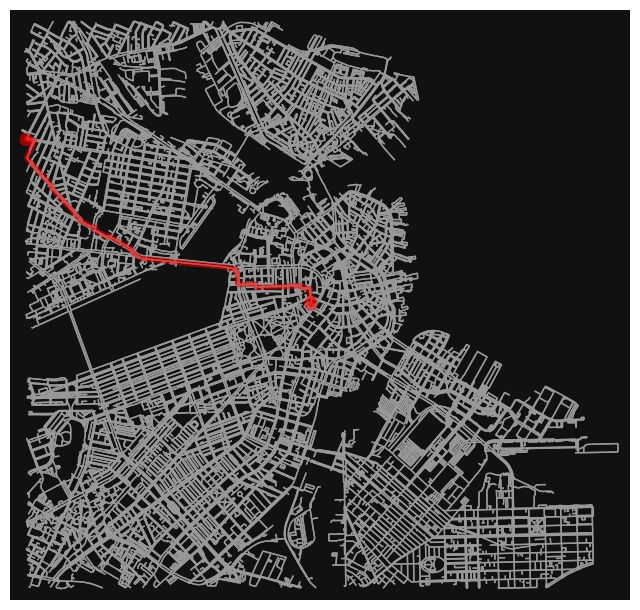

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [5]:
import osmnx as ox
import networkx as nx
import geopandas as gpd

# Define start and end points with example coordinates
start_point = (42.3576, -71.0616)  # Example coordinates
end_point = (42.3736, -71.1097)    # Example coordinates

# Configure OSMnx
ox.settings.use_cache = True

# Get the walking network graph around the start point
G = ox.graph_from_point(start_point, dist=3000, network_type='walk')

# Find the nearest nodes to the start and end points
start_node = ox.distance.nearest_nodes(G, start_point[1], start_point[0])
end_node = ox.distance.nearest_nodes(G, end_point[1], end_point[0])

# Calculate the shortest path
route = nx.shortest_path(G, start_node, end_node, weight='length')

# Plot the route
ox.plot_graph_route(G, route, node_size=0)

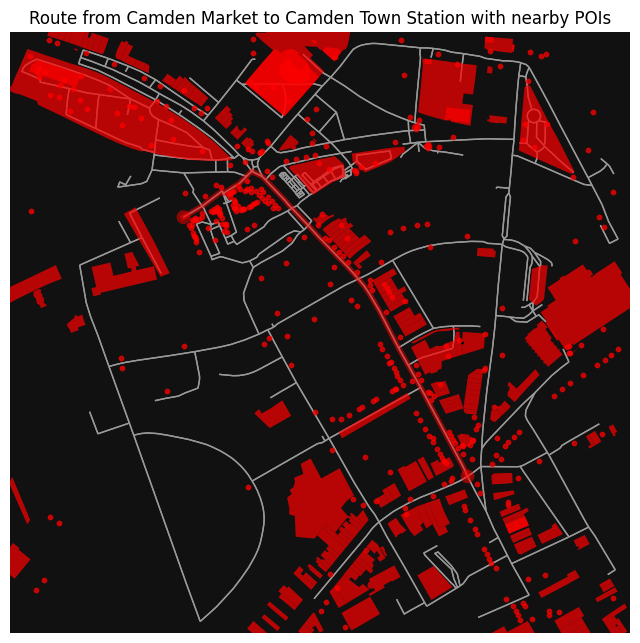

Total POIs in the area: 565


In [10]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

# Define two points within Camden (start and end of your path)
start_point = (51.5415, -0.1468)  # Camden Market area
end_point = (51.5390, -0.1426)    # Camden Town tube station area

# Get the street network covering both points (with some buffer)
# Calculate the midpoint and distance to ensure network covers both points
mid_lat = (start_point[0] + end_point[0]) / 2
mid_lon = (start_point[1] + end_point[1]) / 2
mid_point = (mid_lat, mid_lon)

# Calculate distance from midpoint to furthest point (in meters) plus a buffer
from math import sqrt, cos, radians
dx = 111320 * cos(radians(mid_lat)) * abs(start_point[1] - mid_lon)
dy = 111320 * abs(start_point[0] - mid_lat)
distance = sqrt(dx**2 + dy**2) * 1.5  # 50% buffer

# Get the network
G = ox.graph_from_point(mid_point, dist=distance, network_type='walk')

# Get nearest network nodes to our start and end points
start_node = ox.distance.nearest_nodes(G, start_point[1], start_point[0])
end_node = ox.distance.nearest_nodes(G, end_point[1], end_point[0])

# Calculate the shortest path
route = nx.shortest_path(G, start_node, end_node, weight='length')

# Get POIs near the route
# First, create a buffer around the route
route_coords = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in route]
buffer_dist = 100  # meters

# Get POIs within the buffer area around the route
tags = {
    'amenity': True,
    'leisure': True,
    'shop': True
}
pois = ox.features_from_point(mid_point, tags, dist=distance)

# Visualize the route and nearby POIs
fig, ax = ox.plot_graph_route(G, route, node_size=0, show=False, close=False)
pois.plot(ax=ax, color='red', markersize=10, alpha=0.7)
plt.title("Route from Camden Market to Camden Town Station with nearby POIs")
plt.show()

# Print summary of POIs near the route
print(f"Total POIs in the area: {len(pois)}")

# You could further analyze which POIs are closest to the route
# This would require additional spatial analysis


Shortest Route:
Total length: 473.1 meters
Average safety score: 5.43/10

Safest Route:
Total length: 485.0 meters
Average safety score: 6.57/10


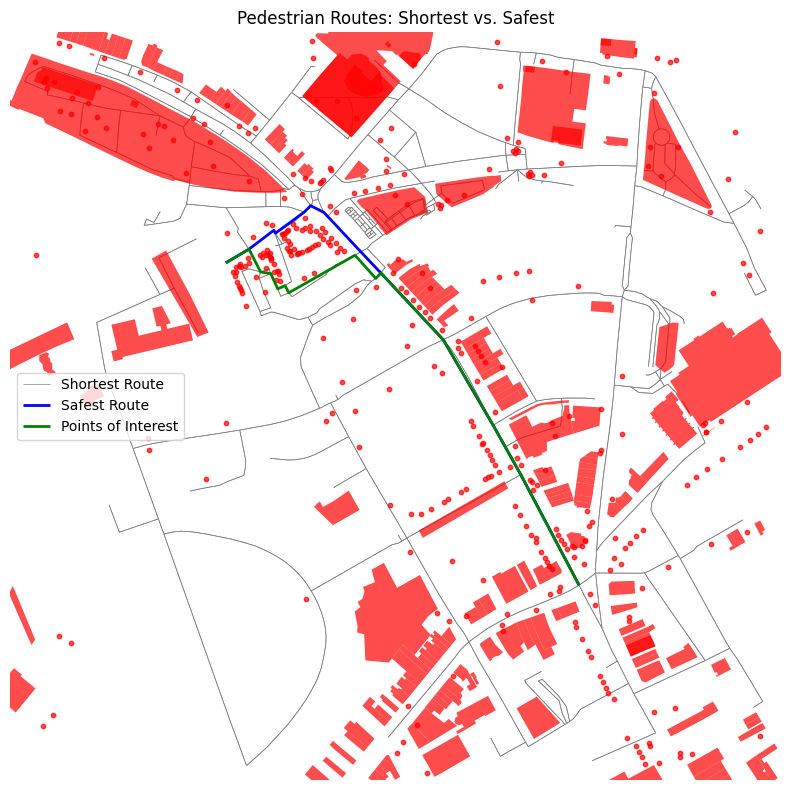

In [12]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString

# Define two points within Camden (start and end of your path)
start_point = (51.5415, -0.1468)  # Camden Market area
end_point = (51.5390, -0.1426)    # Camden Town tube station area

# Get the street network covering both points
mid_lat = (start_point[0] + end_point[0]) / 2
mid_lon = (start_point[1] + end_point[1]) / 2
mid_point = (mid_lat, mid_lon)

# Calculate distance from midpoint to furthest point (in meters) plus a buffer
from math import sqrt, cos, radians
dx = 111320 * cos(radians(mid_lat)) * abs(start_point[1] - mid_lon)
dy = 111320 * abs(start_point[0] - mid_lat)
distance = sqrt(dx**2 + dy**2) * 1.5  # 50% buffer

# Get the network - specifically for walking
G = ox.graph_from_point(mid_point, dist=distance, network_type='walk')

# Add safety-related attributes to the graph based on street features
for u, v, k, data in G.edges(keys=True, data=True):
    # Initialize safety score (higher is better)
    safety_score = 5  # Base score
    
    # Adjust score based on highway type
    highway = data.get('highway', '')
    if isinstance(highway, list):
        highway = highway[0] if highway else ''
    
    # Footways, pedestrian paths are safest
    if highway in ['footway', 'pedestrian', 'path']:
        safety_score += 3
    # Residential streets are relatively safe
    elif highway in ['residential', 'living_street']:
        safety_score += 1
    # Primary roads are less safe for pedestrians
    elif highway in ['primary', 'secondary', 'tertiary']:
        safety_score -= 1
    # Major roads are least safe
    elif highway in ['motorway', 'trunk']:
        safety_score -= 3
    
    # Consider street lighting if available
    if 'lit' in data and data['lit'] == 'yes':
        safety_score += 1
    
    # Consider sidewalk presence
    if 'sidewalk' in data and data['sidewalk'] not in ['no', 'none']:
        safety_score += 2
    
    # Add safety score to edge attributes
    G[u][v][k]['safety_score'] = safety_score
    
    # Create a composite weight that considers both distance and safety
    # Lower values are preferred in shortest_path, so invert safety score
    safety_factor = 10 - safety_score  # Invert so safer paths have lower values
    length = data['length']
    G[u][v][k]['safe_route'] = length * (1 + (safety_factor / 10))  # Length weighted by safety

# Get nearest network nodes to our start and end points
start_node = ox.distance.nearest_nodes(G, start_point[1], start_point[0])
end_node = ox.distance.nearest_nodes(G, end_point[1], end_point[0])

# Calculate the shortest path
shortest_route = nx.shortest_path(G, start_node, end_node, weight='length')

# Calculate the safest path
safest_route = nx.shortest_path(G, start_node, end_node, weight='safe_route')

# Get POIs for context
pois = ox.features_from_point(mid_point, {'amenity': True, 'shop': True, 'leisure': True}, dist=distance)

# Calculate and print route statistics
def calculate_route_stats(G, route, route_type):
    # Calculate total length
    length = 0
    safety_scores = []
    
    # Manually sum up the values for each edge in the route
    for i in range(len(route)-1):
        u = route[i]
        v = route[i+1]
        # Get the first key (usually 0) if there are multiple edges between nodes
        try:
            key = min(G[u][v].keys())
            length += G[u][v][key]['length']
            safety_scores.append(G[u][v][key]['safety_score'])
        except:
            # Skip if edge doesn't exist or doesn't have required attributes
            pass
    
    avg_safety = sum(safety_scores) / len(safety_scores) if safety_scores else 0
    
    print(f"\n{route_type} Route:")
    print(f"Total length: {length:.1f} meters")
    print(f"Average safety score: {avg_safety:.2f}/10")
    return length, avg_safety

shortest_stats = calculate_route_stats(G, shortest_route, "Shortest")
safest_stats = calculate_route_stats(G, safest_route, "Safest")

# Plot both routes for comparison
fig, ax = plt.subplots(figsize=(12, 8))

# Plot the graph and the two routes
ox.plot_graph(G, ax=ax, node_size=0, edge_color='gray', edge_linewidth=0.5, show=False)

# Create route lines for plotting
shortest_route_nodes = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in shortest_route]
safest_route_nodes = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in safest_route]

# Convert to GeoDataFrames for plotting
shortest_line = LineString([(x, y) for y, x in shortest_route_nodes])
safest_line = LineString([(x, y) for y, x in safest_route_nodes])

shortest_gdf = gpd.GeoDataFrame([{'route': 'shortest'}], geometry=[shortest_line], crs="EPSG:4326")
safest_gdf = gpd.GeoDataFrame([{'route': 'safest'}], geometry=[safest_line], crs="EPSG:4326")

# Plot routes
shortest_gdf.plot(ax=ax, color='blue', linewidth=2, label='Shortest Route')
safest_gdf.plot(ax=ax, color='green', linewidth=2, label='Safest Route')

# Plot POIs
if not pois.empty:
    pois.plot(ax=ax, color='red', markersize=10, alpha=0.7)

# Add legend and title
plt.legend(['Shortest Route', 'Safest Route', 'Points of Interest'])
plt.title("Pedestrian Routes: Shortest vs. Safest")
plt.tight_layout()
plt.show()

Current time: 2025-04-11 11:22:40
Is nighttime: False
Route from: Camden Market to Camden Town Station
Start LSOA: E01000001, End LSOA: E01000004
Is daylight: True


C:\Users\Nineli.Lashkarashvil\AppData\Local\Temp\ipykernel_24436\3311162867.py:138: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  edge_buffer = edge_gdf.buffer(buffer_dist).iloc[0]
C:\Users\Nineli.Lashkarashvil\AppData\Local\Temp\ipykernel_24436\3311162867.py:138: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  edge_buffer = edge_gdf.buffer(buffer_dist).iloc[0]
C:\Users\Nineli.Lashkarashvil\AppData\Local\Temp\ipykernel_24436\3311162867.py:138: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  edge_buffer = edge_gdf.buffer(buffer_dist).iloc[0]
C:\Users\Nineli.Lashkarashvil\AppData\Lo


Shortest Route:
Total length: 473.1 meters
Average safety score: 5.09/10

Safest Route:
Total length: 554.8 meters
Average safety score: 6.78/10


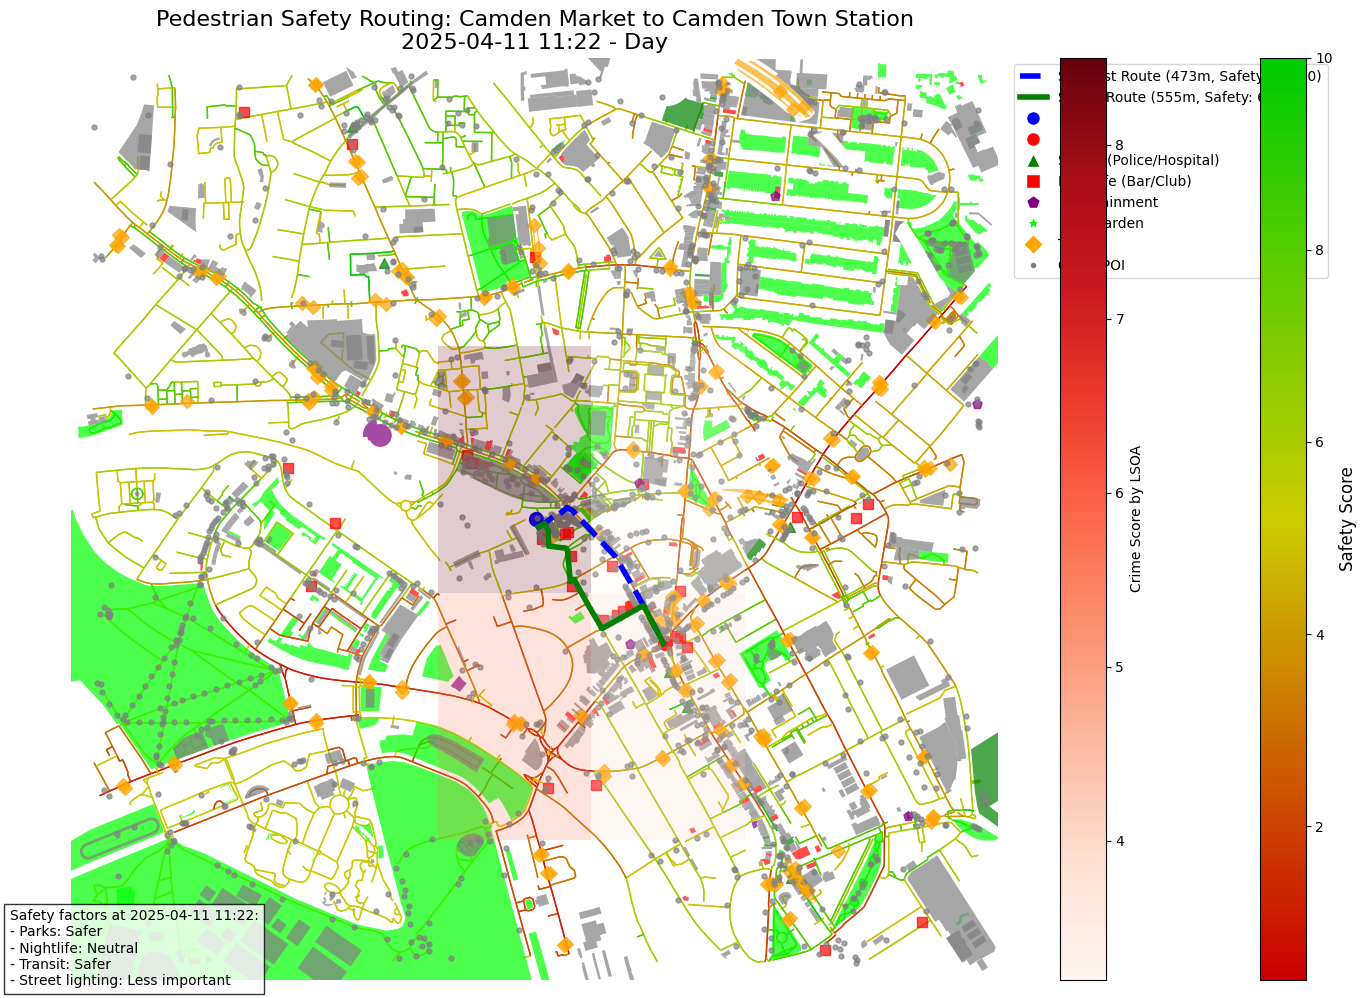


Safety Routing Summary:
Time of analysis: 2025-04-11 11:22 (Day)
Shortest route: 473m with safety score 5.1/10
Safest route: 555m with safety score 6.8/10

Trade-off analysis:
Taking the safest route adds 17.3% distance (82m)
But increases safety by 33.3%

RECOMMENDATION: Take the safer route - the safety benefit outweighs the small increase in distance.

Risk analysis for shortest route:
  - Unlit segments at night: 0 (0.0%)
  - High crime area segments: 9 (64.3%)
  - Major road segments: 9 (64.3%)

Risk analysis for safest route:
  - Unlit segments at night: 0 (0.0%)
  - High crime area segments: 9 (69.2%)
  - Major road segments: 1 (7.7%)

FINAL COMPARISON:
Shortest route (473m): Safety score 5.1/10
Safest route (555m): Safety score 6.8/10
Distance difference: 82m (17.3%)
Safety improvement: 33.3%

RECOMMENDATION: Take the safer route - the safety benefit outweighs the small increase in distance.

Routes saved to GeoJSON files for external use.


In [ ]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon
import datetime
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patches as mpatches
import numpy as np

# Define current time for time-sensitive safety calculations
current_time = datetime.datetime.now()
print(f"Current time: {current_time.strftime('%Y-%m-%d %H:%M:%S')}")

# For testing different times of day:
# current_time = datetime.datetime(2023, 11, 15, 22, 30)  # 10:30 PM
is_night = current_time.hour >= 20 or current_time.hour < 8  # Define night as 8 PM to 8 AM
print(f"Is nighttime: {is_night}")

# Load LSOA crime data (mock function - you would replace with your actual data)
def load_lsoa_crime_data():
    # This would load your actual LSOA crime data
    # Return a dictionary mapping LSOA codes to crime risk scores
    return {
        'E01000001': 8.5,  # High crime area (example)
        'E01000002': 3.2,  # Low crime area (example)
        'E01000003': 5.7,  # Medium crime area (example)
        'E01000004': 4.1,  # Medium-low crime area (example)
        # Add more LSOA codes and scores
    }

# Function to determine LSOA for a given coordinate (mock function)
def get_lsoa_for_coordinate(lat, lon):
    # This would use your actual method to determine LSOA from coordinates
    # For demonstration, we'll create a simple grid-based assignment
    if lat > 51.54 and lon < -0.145:
        return 'E01000001'  # High crime area
    elif lat > 51.54 and lon >= -0.145:
        return 'E01000002'  # Low crime area
    elif lat <= 51.54 and lon < -0.145:
        return 'E01000003'  # Medium crime area
    else:
        return 'E01000004'  # Medium-low crime area

# Function to get sunrise/sunset times for a location (mock function)
def get_sun_times(lat, lon, date):
    # This would use your actual sunrise/sunset data
    return {
        'sunrise': datetime.time(7, 30),  # 7:30 AM
        'sunset': datetime.time(16, 30)   # 4:30 PM
    }

# Load crime data
lsoa_crime_data = load_lsoa_crime_data()

# Define two points within Camden
start_point = (51.5415, -0.1468)  # Camden Market area
end_point = (51.5390, -0.1426)    # Camden Town tube station area
print(f"Route from: Camden Market to Camden Town Station")

# Get LSOA for start and end points
start_lsoa = get_lsoa_for_coordinate(start_point[0], start_point[1])
end_lsoa = get_lsoa_for_coordinate(end_point[0], end_point[1])
print(f"Start LSOA: {start_lsoa}, End LSOA: {end_lsoa}")

# Get the network
G = ox.graph_from_point(start_point, dist=1000, network_type='walk')

# Get sunrise/sunset times for the area
sun_times = get_sun_times(start_point[0], start_point[1], current_time.date())
is_daylight = (current_time.time() > sun_times['sunrise'] and 
               current_time.time() < sun_times['sunset'])
print(f"Is daylight: {is_daylight}")

# Get POIs for safety assessment
safety_pois = ox.features_from_point(start_point, {
    'amenity': True,
    'leisure': True,
    'shop': True,
    'public_transport': True,
    'highway': ['street_lamp']
}, dist=1000)

# Create spatial index for POIs if not empty
if not safety_pois.empty:
    safety_pois_index = safety_pois.sindex

# Add safety scores to the graph
safety_scores = []  # Store for visualization

for u, v, k, data in G.edges(keys=True, data=True):
    # Start with base safety score
    safety_score = 5.0  # Neutral base score
    
    # 1. Road type safety
    highway = data.get('highway', '')
    if isinstance(highway, list):
        highway = highway[0] if highway else ''
    
    if highway in ['footway', 'pedestrian', 'path']:
        safety_score += 3
    elif highway in ['residential', 'living_street']:
        safety_score += 1
    elif highway in ['primary', 'secondary', 'tertiary']:
        safety_score -= 1
    elif highway in ['motorway', 'trunk']:
        safety_score -= 3
    
    # 2. Street lighting (higher impact at night)
    is_lit = data.get('lit') == 'yes'
    if is_lit:
        safety_score += (2 if is_night else 0.5)  # Lighting matters more at night
    elif is_night:
        safety_score -= 2  # Unlit streets are risky at night
    
    # 3. LSOA crime score if different from start/end
    # Get midpoint of the edge for LSOA determination
    edge_midpoint = (
        (G.nodes[u]['y'] + G.nodes[v]['y']) / 2,
        (G.nodes[u]['x'] + G.nodes[v]['x']) / 2
    )
    edge_lsoa = get_lsoa_for_coordinate(edge_midpoint[0], edge_midpoint[1])
    
    # Only consider crime score if in a different LSOA from start/end
    if edge_lsoa != start_lsoa and edge_lsoa != end_lsoa:
        crime_score = lsoa_crime_data.get(edge_lsoa, 5)  # Default to medium if unknown
        # Normalize crime score to our safety scale (higher crime = lower safety)
        safety_score -= (crime_score / 10) * 5  # Scale factor can be adjusted
    
    # 4. Proximity to safety-enhancing or risk-increasing POIs
    if not safety_pois.empty:
        # Create a buffer around the edge to check for nearby POIs
        edge_line = LineString([(G.nodes[u]['x'], G.nodes[u]['y']), 
                                (G.nodes[v]['x'], G.nodes[v]['y'])])
        edge_gdf = gpd.GeoDataFrame(geometry=[edge_line], crs="EPSG:4326")
        buffer_dist = 0.0003  # ~30 meters in decimal degrees
        edge_buffer = edge_gdf.buffer(buffer_dist).iloc[0]
        
        # Find POIs within the buffer
        possible_matches_index = list(safety_pois_index.intersection(edge_buffer.bounds))
        possible_matches = safety_pois.iloc[possible_matches_index]
        precise_matches = possible_matches[possible_matches.intersects(edge_buffer)]
        
        for idx, poi in precise_matches.iterrows():
            poi_type = None
            safety_modifier = 0
            
            # Determine POI type and corresponding safety modifier
            if 'amenity' in poi and poi['amenity'] is not None:
                if poi['amenity'] in ['police', 'hospital', 'pharmacy']:
                    poi_type = 'safety'
                    safety_modifier = 2  # Always safer
                elif poi['amenity'] in ['bar', 'pub', 'casino', 'nightclub']:
                    poi_type = 'nightlife'
                    # Risky at night, neutral during day
                    safety_modifier = -2 if (current_time.hour >= 22 or current_time.hour < 6) else 0
                elif poi['amenity'] in ['theatre', 'cinema', 'arts_centre']:
                    poi_type = 'entertainment'
                    safety_modifier = 0.5  # Generally neutral to slightly positive
            
            elif 'leisure' in poi and poi['leisure'] is not None:
                if poi['leisure'] in ['park', 'garden', 'nature_reserve']:
                    poi_type = 'park'
                    # Parks are safer during day, risky at night
                    if is_daylight and current_time.hour >= 8:
                        safety_modifier = 1
                    else:
                        safety_modifier = -2
            
            elif 'public_transport' in poi and poi['public_transport'] is not None:
                poi_type = 'transit'
                # Transit is safer during commuting hours
                hour = current_time.hour
                if 6 <= hour < 22:
                    safety_modifier = 1
                else:
                    safety_modifier = -1
            
            # Apply the safety modifier
            safety_score += safety_modifier
    
    # Ensure safety score is within reasonable bounds
    safety_score = max(0, min(10, safety_score))
    
    # Store the safety score for the edge
    G[u][v][k]['safety_score'] = safety_score
    safety_scores.append(safety_score)
    
    # Create a composite weight that considers both distance and safety
    # Lower values are preferred in shortest_path, so invert safety score
    safety_factor = 10 - safety_score  # Invert so safer paths have lower values
    length = data['length']
    G[u][v][k]['safe_route'] = length * (1 + (safety_factor / 5))  # Length weighted by safety

# Get nearest network nodes to our start and end points
start_node = ox.distance.nearest_nodes(G, start_point[1], start_point[0])
end_node = ox.distance.nearest_nodes(G, end_point[1], end_point[0])

# Calculate the shortest path
shortest_route = nx.shortest_path(G, start_node, end_node, weight='length')

# Calculate the safest path
safest_route = nx.shortest_path(G, start_node, end_node, weight='safe_route')

# Calculate and print route statistics
def calculate_route_stats(G, route, route_type):
    # Calculate total length
    length = 0
    safety_scores = []
    
    # Manually sum up the values for each edge in the route
    for i in range(len(route)-1):
        u = route[i]
        v = route[i+1]
        # Get the first key (usually 0) if there are multiple edges between nodes
        try:
            key = min(G[u][v].keys())
            length += G[u][v][key]['length']
            safety_scores.append(G[u][v][key]['safety_score'])
        except:
            # Skip if edge doesn't exist or doesn't have required attributes
            pass
    
    avg_safety = sum(safety_scores) / len(safety_scores) if safety_scores else 0
    
    print(f"\n{route_type} Route:")
    print(f"Total length: {length:.1f} meters")
    print(f"Average safety score: {avg_safety:.2f}/10")
    return length, avg_safety

shortest_stats = calculate_route_stats(G, shortest_route, "Shortest")
safest_stats = calculate_route_stats(G, safest_route, "Safest")

# Prepare data for visualization
# 1. Create a colormap for safety scores
safety_min = min(safety_scores) if safety_scores else 0
safety_max = max(safety_scores) if safety_scores else 10

# Create a custom colormap: red (unsafe) to green (safe)
colors = [(0.8, 0.0, 0.0), (0.8, 0.8, 0.0), (0.0, 0.8, 0.0)]  # Red -> Yellow -> Green
cmap_name = 'safety_cmap'
cm = LinearSegmentedColormap.from_list(cmap_name, colors, N=100)

# Normalize safety scores for coloring
norm = plt.Normalize(safety_min, safety_max)

# Create figure and axis for plotting
fig, ax = plt.subplots(figsize=(15, 10))

# Plot the base network with safety coloring
edge_colors = []
edge_widths = []

for u, v, k, data in G.edges(keys=True, data=True):
    safety = data.get('safety_score', 5)  # Default to neutral if not set
    edge_colors.append(cm(norm(safety)))
    edge_widths.append(1)  # Base width for all edges

# Plot the base network
ox.plot_graph(G, ax=ax, node_size=0, edge_color=edge_colors, 
              edge_linewidth=edge_widths, show=False, close=False)

# Create route lines for plotting
shortest_route_nodes = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in shortest_route]
safest_route_nodes = [(G.nodes[node]['y'], G.nodes[node]['x']) for node in safest_route]

# Convert to GeoDataFrames for plotting
shortest_line = LineString([(x, y) for y, x in shortest_route_nodes])
safest_line = LineString([(x, y) for y, x in safest_route_nodes])

shortest_gdf = gpd.GeoDataFrame([{'route': 'shortest'}], geometry=[shortest_line], crs="EPSG:4326")
safest_gdf = gpd.GeoDataFrame([{'route': 'safest'}], geometry=[safest_line], crs="EPSG:4326")

# Plot routes with thicker lines
shortest_gdf.plot(ax=ax, color='blue', linewidth=4, linestyle='--', label='Shortest Route')
safest_gdf.plot(ax=ax, color='green', linewidth=4, linestyle='-', label='Safest Route')

# Plot start and end points
start_gdf = gpd.GeoDataFrame([{'point': 'start'}], 
                             geometry=[Point(start_point[1], start_point[0])], 
                             crs="EPSG:4326")
end_gdf = gpd.GeoDataFrame([{'point': 'end'}], 
                           geometry=[Point(end_point[1], end_point[0])], 
                           crs="EPSG:4326")

start_gdf.plot(ax=ax, color='blue', markersize=100, marker='o', label='Start')
end_gdf.plot(ax=ax, color='red', markersize=100, marker='o', label='End')

# Plot POIs with different colors based on type
if not safety_pois.empty:
    # Define POI categories and colors
    poi_categories = {
        'safety': {'color': 'green', 'marker': '^', 'label': 'Safety (Police/Hospital)'},
        'nightlife': {'color': 'red', 'marker': 's', 'label': 'Nightlife (Bar/Club)'},
        'entertainment': {'color': 'purple', 'marker': 'p', 'label': 'Entertainment'},
        'park': {'color': 'lime', 'marker': '*', 'label': 'Park/Garden'},
        'transit': {'color': 'orange', 'marker': 'D', 'label': 'Transit'},
        'other': {'color': 'gray', 'marker': '.', 'label': 'Other POI'}
    }
    
    # Create a GeoDataFrame
        # Create a GeoDataFrame for each POI category
    # Modify the POI filtering section to handle empty geometries correctly

# Create a GeoDataFrame for each POI category
for category, style in poi_categories.items():
    # Filter POIs by category
    if category == 'safety':
        mask = safety_pois['amenity'].isin(['police', 'hospital', 'pharmacy'])
    elif category == 'nightlife':
        mask = safety_pois['amenity'].isin(['bar', 'pub', 'casino', 'nightclub'])
    elif category == 'entertainment':
        mask = safety_pois['amenity'].isin(['theatre', 'cinema', 'arts_centre'])
    elif category == 'park':
        mask = safety_pois['leisure'].isin(['park', 'garden', 'nature_reserve'])
    elif category == 'transit':
        mask = safety_pois['public_transport'].notna()
    else:  # 'other'
        # All POIs not in other categories
        mask1 = ~safety_pois['amenity'].isin(['police', 'hospital', 'pharmacy', 
                                            'bar', 'pub', 'casino', 'nightclub',
                                            'theatre', 'cinema', 'arts_centre'])
        mask2 = ~safety_pois['leisure'].isin(['park', 'garden', 'nature_reserve'])
        mask3 = safety_pois['public_transport'].isna()
        mask = mask1 & mask2 & mask3
    
    # Apply the filter and plot if we have results
    try:
        # Handle potential missing columns by checking first
        for col in ['amenity', 'leisure', 'public_transport']:
            if col not in safety_pois.columns:
                safety_pois[col] = None
        
        # Apply the mask and check if we have results
        filtered_pois = safety_pois[mask]
        
        if not filtered_pois.empty and 'geometry' in filtered_pois.columns:
            # Plot only if we have geometries
            filtered_pois.plot(ax=ax, color=style['color'], marker=style['marker'], 
                            markersize=50, label=style['label'], alpha=0.7)
    except Exception as e:
        print(f"Error plotting {category} POIs: {e}")
        continue
# Add a colorbar for safety scores
sm = plt.cm.ScalarMappable(cmap=cm, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation='vertical', pad=0.01)
cbar.set_label('Safety Score', fontsize=12)

# Add LSOA boundaries with crime levels (simplified for demo)
# In a real implementation, you'd use actual LSOA boundary data
# Here we're creating a simple grid to represent different LSOAs
lsoa_bounds = {
    'E01000001': Polygon([(-0.150, 51.545), (-0.145, 51.545), (-0.145, 51.540), (-0.150, 51.540)]),
    'E01000002': Polygon([(-0.145, 51.545), (-0.140, 51.545), (-0.140, 51.540), (-0.145, 51.540)]),
    'E01000003': Polygon([(-0.150, 51.540), (-0.145, 51.540), (-0.145, 51.535), (-0.150, 51.535)]),
    'E01000004': Polygon([(-0.145, 51.540), (-0.140, 51.540), (-0.140, 51.535), (-0.145, 51.535)])
}

# Create a GeoDataFrame for LSOA boundaries
lsoa_data = {
    'LSOA': list(lsoa_bounds.keys()),
    'crime_score': [lsoa_crime_data.get(lsoa, 5) for lsoa in lsoa_bounds.keys()],
    'geometry': list(lsoa_bounds.values())
}

lsoa_gdf = gpd.GeoDataFrame(lsoa_data, crs="EPSG:4326")

# Plot LSOA boundaries with transparency based on crime score
lsoa_gdf.plot(ax=ax, column='crime_score', cmap='Reds', alpha=0.2, 
              legend=True, legend_kwds={'label': "Crime Score by LSOA"})

# Add a title with time information
time_str = current_time.strftime('%Y-%m-%d %H:%M')
title = f"Pedestrian Safety Routing: Camden Market to Camden Town Station\n{time_str} - {'Night' if is_night else 'Day'}"
plt.title(title, fontsize=16)

# Create a custom legend for routes and points
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', linestyle='--', lw=4, label=f'Shortest Route ({shortest_stats[0]:.0f}m, Safety: {shortest_stats[1]:.1f}/10)'),
    Line2D([0], [0], color='green', linestyle='-', lw=4, label=f'Safest Route ({safest_stats[0]:.0f}m, Safety: {safest_stats[1]:.1f}/10)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='blue', markersize=10, label='Start'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=10, label='End')
]

# Add POI categories to legend
for category, style in poi_categories.items():
    legend_elements.append(
        Line2D([0], [0], marker=style['marker'], color='w', 
               markerfacecolor=style['color'], markersize=10, 
               label=style['label'])
    )

# Add the legend
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.01, 1), 
          fontsize=10, frameon=True)

# Add a note about time-sensitive safety factors
time_note = (
    f"Safety factors at {time_str}:\n"
    f"- Parks: {'Safer' if (is_daylight and current_time.hour >= 8) else 'Riskier'}\n"
    f"- Nightlife: {'Riskier' if (current_time.hour >= 22 or current_time.hour < 6) else 'Neutral'}\n"
    f"- Transit: {'Safer' if (6 <= current_time.hour < 22) else 'Riskier'}\n"
    f"- Street lighting: {'Very important' if is_night else 'Less important'}"
)
plt.figtext(0.01, 0.01, time_note, fontsize=10, bbox=dict(facecolor='white', alpha=0.8))

plt.tight_layout()
plt.savefig('safety_route_map.png', dpi=300, bbox_inches='tight')
plt.show()

# Print additional information
print("\nSafety Routing Summary:")
print(f"Time of analysis: {time_str} ({'Night' if is_night else 'Day'})")
print(f"Shortest route: {shortest_stats[0]:.0f}m with safety score {shortest_stats[1]:.1f}/10")
print(f"Safest route: {safest_stats[0]:.0f}m with safety score {safest_stats[1]:.1f}/10")

# Calculate the safety vs. distance tradeoff
distance_increase = ((safest_stats[0] - shortest_stats[0]) / shortest_stats[0]) * 100
safety_increase = ((safest_stats[1] - shortest_stats[1]) / shortest_stats[1]) * 100 if shortest_stats[1] > 0 else float('inf')

print(f"\nTrade-off analysis:")
print(f"Taking the safest route adds {distance_increase:.1f}% distance ({safest_stats[0] - shortest_stats[0]:.0f}m)")
print(f"But increases safety by {safety_increase:.1f}%")

# Recommendation based on time of day and safety difference
safety_threshold = 2.0  # Minimum safety improvement to recommend the safer route
distance_threshold = 20.0  # Maximum acceptable distance increase (%)

if safety_increase > safety_threshold and distance_increase < distance_threshold:
    recommendation = "RECOMMENDATION: Take the safer route - the safety benefit outweighs the small increase in distance."
elif safety_increase > safety_threshold * 2 and distance_increase < distance_threshold * 1.5:
    recommendation = "RECOMMENDATION: Strongly consider the safer route - significant safety improvement for moderate distance increase."
elif is_night and safety_increase > safety_threshold / 2:
    recommendation = "RECOMMENDATION: Consider the safer route as it's nighttime and safety risks are elevated."
else:
    recommendation = "RECOMMENDATION: Take the shorter route - the safety benefit doesn't justify the increased distance."

print(f"\n{recommendation}")

# Additional analysis of specific risk factors along the routes
def analyze_route_risks(G, route, route_type):
    print(f"\nRisk analysis for {route_type} route:")
    
    # Track risk factors
    risks = {
        'unlit_night_segments': 0,
        'high_crime_areas': 0,
        'nightlife_night': 0,
        'park_night': 0,
        'transit_late': 0,
        'major_roads': 0
    }
    
    total_segments = len(route) - 1
    
    for i in range(len(route)-1):
        u = route[i]
        v = route[i+1]
        try:
            key = min(G[u][v].keys())
            data = G[u][v][key]
            
            # Check for unlit streets at night
            if is_night and data.get('lit') != 'yes':
                risks['unlit_night_segments'] += 1
            
            # Check for high crime areas
            edge_midpoint = (
                (G.nodes[u]['y'] + G.nodes[v]['y']) / 2,
                (G.nodes[u]['x'] + G.nodes[v]['x']) / 2
            )
            edge_lsoa = get_lsoa_for_coordinate(edge_midpoint[0], edge_midpoint[1])
            crime_score = lsoa_crime_data.get(edge_lsoa, 5)
            if crime_score > 7:  # Threshold for high crime
                risks['high_crime_areas'] += 1
            
            # Check for major roads (less safe for pedestrians)
            highway = data.get('highway', '')
            if isinstance(highway, list):
                highway = highway[0] if highway else ''
            if highway in ['primary', 'secondary', 'tertiary', 'motorway', 'trunk']:
                risks['major_roads'] += 1
                
            # Other risk factors would be checked here based on proximity to POIs
            # This would require more complex spatial analysis in a real implementation
            
        except:
            continue
    
    # Print risk summary
    if total_segments > 0:
        print(f"  - Unlit segments at night: {risks['unlit_night_segments']} ({risks['unlit_night_segments']/total_segments*100:.1f}%)")
        print(f"  - High crime area segments: {risks['high_crime_areas']} ({risks['high_crime_areas']/total_segments*100:.1f}%)")
        print(f"  - Major road segments: {risks['major_roads']} ({risks['major_roads']/total_segments*100:.1f}%)")
    
    return risks

# Analyze risks for both routes
shortest_risks = analyze_route_risks(G, shortest_route, "shortest")
safest_risks = analyze_route_risks(G, safest_route, "safest")

# Final summary comparing the two routes
print("\nFINAL COMPARISON:")
print(f"Shortest route ({shortest_stats[0]:.0f}m): Safety score {shortest_stats[1]:.1f}/10")
print(f"Safest route ({safest_stats[0]:.0f}m): Safety score {safest_stats[1]:.1f}/10")
print(f"Distance difference: {safest_stats[0] - shortest_stats[0]:.0f}m ({distance_increase:.1f}%)")
print(f"Safety improvement: {safety_increase:.1f}%")
print(f"\n{recommendation}")

# Save the routes to GeoJSON for possible use in other applications
shortest_gdf.to_file("shortest_route.geojson", driver="GeoJSON")
safest_gdf.to_file("safest_route.geojson", driver="GeoJSON")

print("\nRoutes saved to GeoJSON files for external use.")

In [7]:
def score_route(route, pois, G):
    """
    Score the route based on urban density and inferred lighting from POIs.
    """
    # Convert the route to a GeoDataFrame
    route_nodes = [Point((G.nodes[node]['x'], G.nodes[node]['y'])) for node in route]
    route_line = LineString(route_nodes)
    route_gdf = gpd.GeoDataFrame([1], geometry=[route_line], crs="EPSG:4326")
    
    # Calculate proximity of POIs to the route
    pois['distance_to_route'] = pois.distance(route_gdf.geometry.unary_union)
    
    # Score based on density of nearby POIs
    nearby_pois = pois[pois['distance_to_route'] < 0.001]  # Adjust proximity threshold as needed
    score = len(nearby_pois)
    
    return score

# Score the route
route_score = score_route(route, pois, G)
print(f"Route Score based on Urban Density and POIs: {route_score}")

NameError: name 'pois' is not defined